In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside Jupyter Notebook
%matplotlib inline

In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\STARBWOY\Titanic_Project\train.csv")

df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Dataset dimensions (rows, columns)
print("Dataset Shape:", df.shape)

Dataset Shape: (891, 12)


In [4]:
# Column names
print("Column Names:")
print(df.columns)

Column Names:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')


In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# Data types
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


In [7]:
df.info() #gives a cleaner summary because it also shows the number of non-null values in each column.

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [8]:
#The Titanic dataset was imported into Python using the Pandas library.
#The dataset contains 891 rows and 12 columns, representing passenger 
#information such as age, gender, ticket class, fare, and survival status.
#The dataset includes both numerical and categorical variables, 
#making it suitable for exploratory data analysis and machine learning.

In [9]:
# Check for missing values
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [10]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [11]:
# Fill missing Age values with the median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with the mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop the Cabin column because it has too many missing values
df = df.drop(columns=["Cabin"])

In [12]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


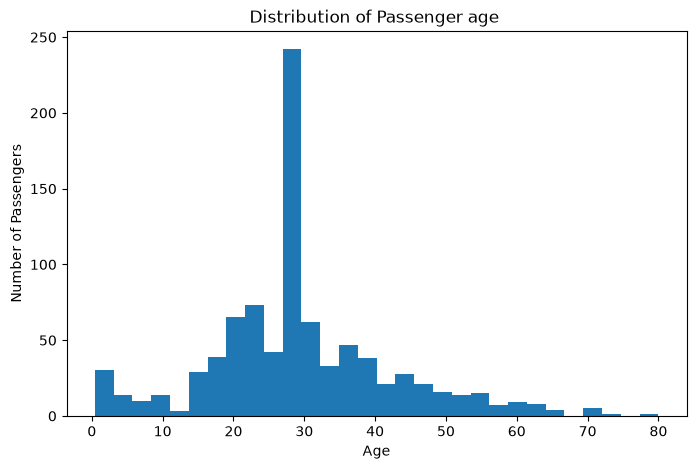

In [15]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=30)

plt.title("Distribution of Passenger age ")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

In [16]:
# The histogram shows that most passengers were between 20 and 40 years old. There were relatively fewer children and elderly passengers.

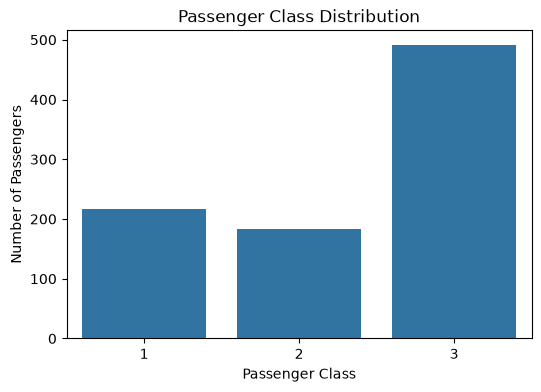

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Pclass")

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

In [18]:
# Most passengers travelled in Third Class, followed by First Class, while Second Class had the fewest passengers.

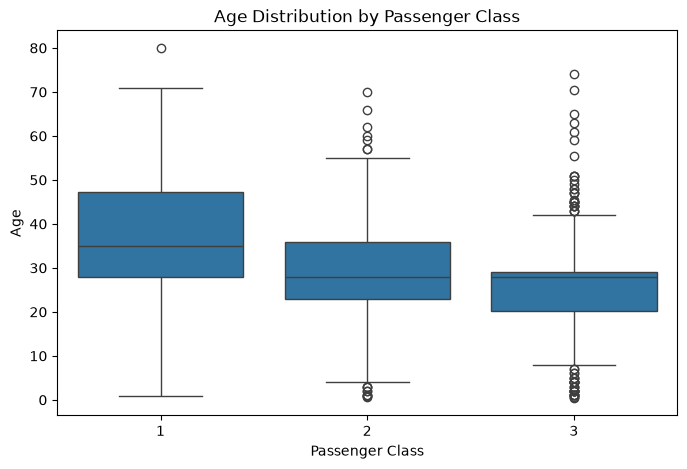

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Pclass", y="Age")

plt.title("Age Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Age")

plt.show()

In [20]:
# The boxplot shows the distribution of passenger ages within each class. 
# It also highlights outliers and differences in age spread across the passenger classes.

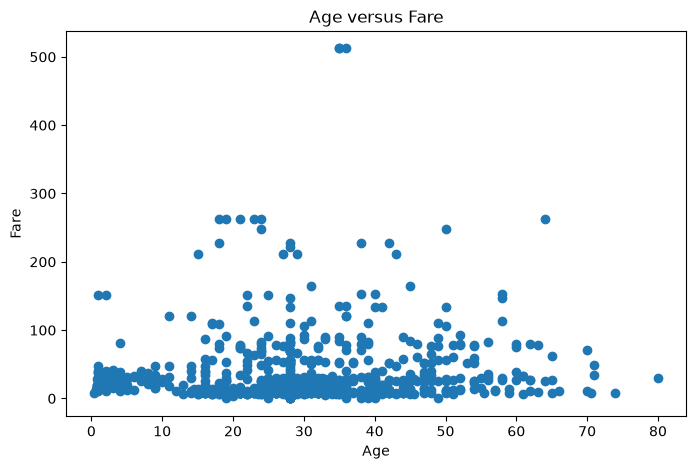

In [21]:
plt.figure(figsize=(8,5))

plt.scatter(df["Age"], df["Fare"])

plt.title("Age versus Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

In [22]:
# Most passengers paid relatively low fares regardless of age. A few passengers paid significantly higher fares, appearing as outliers.

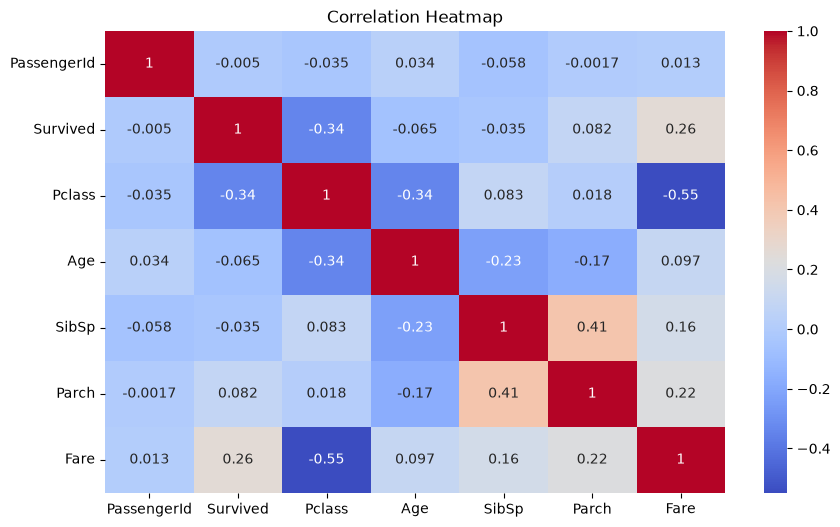

In [23]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [24]:
# The heatmap shows the strength and direction of relationships between numerical variables. 
# Darker colours indicate stronger positive or negative correlations.

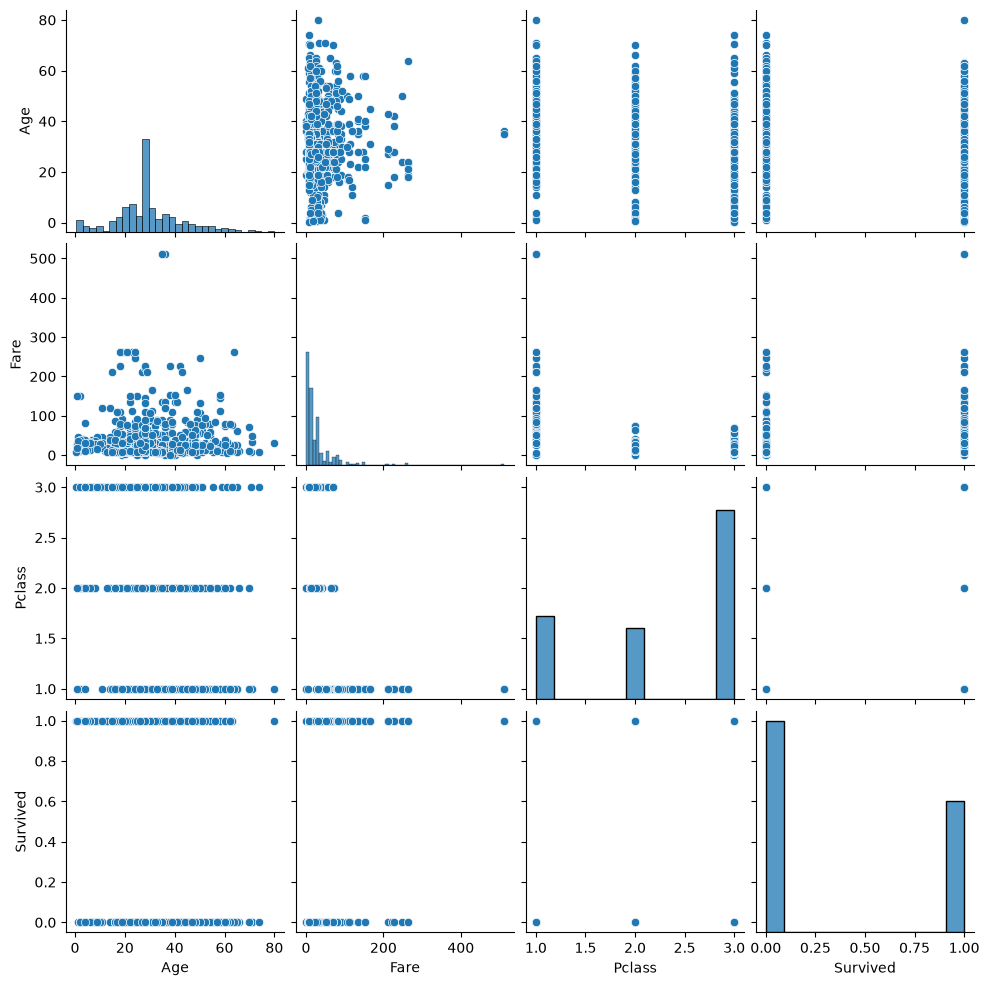

In [25]:
sns.pairplot(
    df[["Age", "Fare", "Pclass", "Survived"]]
)

plt.show()

In [26]:
#The pairplot illustrates relationships among age, fare, passenger class, and survival. 
# It helps identify trends, clusters, and potential correlations between variables.

In [27]:
# Descriptive statistics
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [28]:
# The descriptive statistics provide a summary of the numerical variables in the dataset. 
# They show measures of central tendency (mean and median), 
# variability (standard deviation), and the range of each variable.

In [29]:
print(df["Pclass"].value_counts())

Pclass
3    491
1    216
2    184
Name: count, dtype: int64


In [30]:
print(df["Sex"].value_counts())

Sex
male      577
female    314
Name: count, dtype: int64


In [31]:
print(df["Survived"].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


In [32]:
print(df["Survived"].value_counts(normalize=True) * 100)

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [33]:
# This is the percentage wise when it comes to the survivers.
# The frequency distributions show how passengers are distributed across different categories 
# such as passenger class, gender, and survival status.

In [34]:
numeric_df = df.select_dtypes(include=["number"])

corr_matrix = numeric_df.corr()

corr_matrix

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.034212,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
Age,0.034212,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
SibSp,-0.057527,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


In [35]:
corr_matrix

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.034212,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
Age,0.034212,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
SibSp,-0.057527,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


In [37]:
# Finding 1

# Most passengers travelled in Third Class, indicating that it was the most common ticket category.

# Finding 2

# Passenger fare generally decreased as passenger class number increased, showing a strong negative relationship between fare and class.

# Finding 3

# The median age was around 28 years, indicating that most passengers were young adults.

In [38]:
corr_matrix

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.034212,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
Age,0.034212,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
SibSp,-0.057527,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


In [39]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [40]:
# The Titanic dataset contains information on 891 passengers. 
# The average passenger age is approximately 29 years, while the average ticket fare is 32.20. 
# Passenger ages range from 0.42 years to 80 years, indicating a diverse age distribution. 
# The survival rate in the dataset is approximately 38%, 
# meaning that fewer than half of the passengers survived the disaster.

In [41]:
# Strongest Positive Correlation

# Ignoring the diagonal values of 1.0, the strongest positive correlation is:

# SibSp ↔ Parch = 0.4148

# This means passengers travelling with siblings/spouses often also travelled with parents or children.

# Strongest Negative Correlation
# Pclass ↔ Fare = -0.5495

# This indicates that passengers in higher-numbered classes (especially Third Class) generally paid lower fares than those in First Class.

# Three Statistical Findings

# Finding 1

# Passenger class has a moderate negative correlation (-0.338) with survival, suggesting that passengers travelling in First Class 
# were more likely to survive than those in Third Class.

# Finding 2

# Ticket fare has a moderate positive correlation (0.257) with survival, indicating that passengers who paid higher fares had a
# greater chance of surviving.

# Finding 3

# The strongest positive relationship exists between the number of siblings/spouses (SibSp) and parents/children (Parch), 
# suggesting that family members often travelled together.

In [42]:
from sklearn.preprocessing import LabelEncoder

# Make a copy of the cleaned dataset
ml_df = df.copy()

# Convert categorical columns into numbers
encoder = LabelEncoder()

ml_df["Sex"] = encoder.fit_transform(ml_df["Sex"])
ml_df["Embarked"] = encoder.fit_transform(ml_df["Embarked"])

# Select predictor variables
X = ml_df[["Pclass", "Sex", "Age", "Fare", "SibSp", "Parch", "Embarked"]]

# Target variable
y = ml_df["Survived"]

# Display the first five rows
X.head()

,Pclass,Sex,Age,Fare,SibSp,Parch,Embarked
0,3,1,22.0,7.2500,1,0,2
1,1,0,38.0,71.2833,1,0,0
2,3,0,26.0,7.9250,0,0,2
3,1,0,35.0,53.1000,1,0,2
4,3,1,35.0,8.0500,0,0,2


In [43]:
from sklearn.model_selection import train_test_split

# Split the data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (712, 7)
Testing set: (179, 7)


In [44]:
# Split the Dataset
# The purpose of this step is to train the model on one part of the data and test it on another part to evaluate how well it performs on unseen data.

In [45]:
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [46]:
# Predict the test data
y_pred = model.predict(X_test)

print(y_pred[:10])

# This shows the first 10 predictions made by the model.

[0 0 0 1 1 1 1 0 1 1]


In [47]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred))

# This is to evaluate the model

Accuracy: 0.8100558659217877

Confusion Matrix
[[90 15]
 [19 55]]

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [ ]:
# Model Accuracy
# The model achieved an accuracy of 81.01%.
# Interpretation
# The Logistic Regression model correctly predicted the survival status of approximately 81% of the passengers in the testing dataset. 
# This indicates that the model performs well in distinguishing between passengers who survived and those who did not.

# Confusion Matrix
# The confusion matrix is:
# Actual / Predicted	Did Not Survive	     Survived
# Did Not Survive	        90                   15
# Survived	                19	                 55
# Interpretation
# 90 passengers who did not survive were correctly classified.
# 55 passengers who survived were correctly classified.
# 15 passengers were incorrectly predicted to have survived.
# 19 passengers were incorrectly predicted not to have survived.

# Classification Report
# Metric	Class 0	Class 1
# Precision	0.83	0.79
# Recall	0.86	0.74
# F1-score	0.84	0.76
# Interpretation
# The model has 83% precision for predicting non-survivors.
# It correctly identified 86% of actual non-survivors (recall).
# For survivors, the model achieved 79% precision and 74% recall.
# The weighted F1-score of 0.81 indicates a balanced overall performance.

# Major Findings
# The Titanic dataset contains 891 passenger records.
# Most passengers travelled in Third Class.
# The average passenger age was approximately 29 years.
# Around 38% of passengers survived.
# Passenger class and fare showed important relationships with survival.

# Statistical Insights
# Passenger class was negatively correlated with fare (-0.5495).
# Passengers travelling with family members tended to have positive relationships between SibSp and Parch (0.4148).
# Higher ticket fares were associated with a greater likelihood of survival.

# Machine Learning Results
# Logistic Regression achieved an accuracy of 81.01%.
# The model correctly classified most passengers.
# Some prediction errors remained, particularly for survivors.

# Limitations
# The model used only a limited set of features.
# Missing values had to be imputed.
# The Cabin column was removed due to extensive missing data.
# More advanced models (such as Random Forest or Gradient Boosting) might improve prediction accuracy.

# Recommendations
# Explore additional feature engineering (e.g., extracting titles from passenger names or creating family-size features).
# Compare Logistic Regression with other classification algorithms.
# Use cross-validation to further evaluate model robustness.

